# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Piros
- **Email:** firasmuhsaid@gmail.com
- **ID Dicoding:** CDCC657D6Y2101

## Menentukan Pertanyaan Bisnis

1. Negara bagian (customer_state) mana yang memberikan kontribusi total pendapatan (revenue) tertinggi dari pesanan berstatus 'delivered' selama tahun 2018 untuk menentukan prioritas efisiensi distribusi?
2. Apa saja 5 kategori produk dengan volume penjualan terbanyak selama periode 2017-2018 dan bagaimana kontribusinya terhadap total pendapatan guna mengoptimalkan manajemen stok inventaris?

## Import Semua Packages/Library yang Digunakan

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.preprocessing import StandardScaler

## Data Wrangling

### Gathering Data

In [6]:
# Memuat data pelanggan dan pesanan
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [10]:
translation_df = pd.read_csv("product_category_name_translation.csv")
translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Tabel order_items adalah tabel yang menjadi penghubung utama karena tabel tersebut menghubungkan data pesanan (order_id) dengan data produk (product_id).
- Jika di perhatikan jumlah baris, di ditu terlihat kalau jumlah ordres_item lebih banyak di bandingkan orders.
- Di tabel customers_df, kolom customer_state sangat bersih. Namun, di tabel products_df, masih terdapat kolom product_category_name yang kosong.
- Ada produk yang menggunakan bahasa Portugis di kategori produk utama contohnya beleza_saude.

### Assessing Data

In [11]:
print("\nInformasi Data Customers:")
customers_df.info()


Informasi Data Customers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [12]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [13]:
print ("Jumlah duplikasi data: ",customers_df.duplicated().sum())

Jumlah duplikasi data:  0


In [14]:
# Menampilkan info jumlah baris dan tipe data dari tabel order
print("\nInformasi Data Orders:")
orders_df.info()


Informasi Data Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [15]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [16]:
print ("Jumlah duplikasi data: ",orders_df.duplicated().sum())

Jumlah duplikasi data:  0


In [17]:
# Menampilkan info jumlah baris dan tipe data dari tabel order_items
print("\nInformasi Data Order_items:")
order_items_df.info()


Informasi Data Order_items:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [18]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [19]:
print ("Jumlah duplikasi data: ",order_items_df.duplicated().sum())

Jumlah duplikasi data:  0


In [20]:
# Menampilkan info jumlah baris dan tipe data dari tabel trnaslation_df
print("\nInformasi Data trnaslation_df:")
translation_df.info()


Informasi Data trnaslation_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [21]:
translation_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [22]:
print ("Jumlah duplikasi data: ", translation_df.duplicated().sum())

Jumlah duplikasi data:  0


In [23]:
# Menampilkan info jumlah baris dan tipe data dari tabel product_dataset
print("\nInformasi Data products_dataset:")
products_df.info()


Informasi Data products_dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [24]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [25]:
print ("Jumlah duplikasi data: ", products_df.duplicated().sum())

Jumlah duplikasi data:  0


**Insight:**
- Integritas Data: Seluruh tabel tidak memiliki data duplikat, artinya data transaksi dan pelanggan bersifat unik dan aman untuk diolah lebih lanjut.

- Kualitas Tabel Orders: Ditemukan missing value pada kolom terkait pengiriman (terutama order_delivered_customer_date sebanyak 2.965). Hal ini mengindikasikan adanya pesanan yang tidak sampai ke pelanggan (batal/proses). Tindakan: Data ini akan difilter pada tahap Cleaning agar analisis pendapatan lebih akurat.

- Kualitas Tabel Products: Terdapat 610 data kategori produk yang kosong.
Tindakan: Untuk menjaga total volume penjualan, data ini tidak akan dihapus melainkan diberi label 'Unknown'.

### Cleaning Data

In [26]:
orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()

In [27]:
# Mengubah kolom yang berisi informasi tanggal menjadi tipe data datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [28]:
orders_df[orders_df.order_delivered_customer_date.isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [29]:
orders_df = orders_df.dropna(subset=['order_delivered_customer_date'])

In [30]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,1
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [31]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('Unknown')

In [32]:
print("Jumlah data kosong setelah diisi:")
print(products_df['product_category_name'].isna().sum())

Jumlah data kosong setelah diisi:
0


**Insight:**
- Penyaringan Status Pesanan: Data pada tabel orders_df difilter untuk hanya menyertakan pesanan dengan status 'delivered'. Hal ini dilakukan karena pendapatan (revenue) hanya dapat dihitung dari transaksi yang sudah benar-benar selesai dan barang telah diterima oleh pelanggan. Baris yang memiliki nilai kosong (missing value) pada tanggal pengiriman otomatis dihapus dalam proses ini.

- Penanganan Kategori Produk: Ditemukan sejumlah produk yang tidak memiliki nama kategori. Alih-alih menghapus baris tersebut (yang dapat menyebabkan hilangnya data transaksi), dilakukan pengisian nilai kosong menggunakan label 'Unknown'. Langkah ini memastikan seluruh volume penjualan tetap terdata secara akurat meskipun identitas kategorinya tidak diketahui.

- Standarisasi Tipe Data: Kolom-kolom yang berkaitan dengan waktu (seperti tanggal pesanan dan tanggal pengiriman) dipastikan telah dikonversi ke tipe data datetime. Hal ini sangat penting untuk mencegah kesalahan sistem saat melakukan analisis tren waktu di tahap selanjutnya.

- Konsistensi Informasi: Walaupun masih terdapat beberapa nilai kosong pada kolom pendukung seperti order_approved_at, data tersebut tetap dipertahankan. Hal ini dikarenakan kolom-kolom tersebut tidak memengaruhi hasil perhitungan pada pertanyaan bisnis utama mengenai pendapatan per wilayah dan kategori produk.

## Exploratory Data Analysis (EDA)

### Explore ...

1. Negara bagian (customer_state) mana yang menghasilkan total pendapatan (total revenue) tertinggi dari pesanan yang berstatus "delivered" selama seluruh periode transaksi di dataset?

In [33]:
# Menggabungkan tabel orders_df, customers_df, dan order_items_df
merge_q1 = pd.merge(orders_df, customers_df, on='customer_id')
data_q1 = pd.merge(merge_q1, order_items_df, on='order_id')

In [34]:
# Melakukan grouping berdasarkan customer_state dan menjumlahkan price
state_revenue = data_q1.groupby(by='customer_state')['price'].sum().sort_values(ascending=False).reset_index()

In [35]:
print("Top 5 Negara Bagian Berdasarkan Pendapatan (Revenue):")
display(state_revenue.head())

Top 5 Negara Bagian Berdasarkan Pendapatan (Revenue):


,customer_state,price
0,SP,5066562.98
1,RJ,1759651.13
2,MG,1552481.83
3,RS,728718.47
4,PR,666063.51


2. Apa saja 5 kategori produk dengan volume penjualan terbanyak dan bagaimana perbandingannya dengan total nilai pendapatan yang dihasilkan?

In [36]:
products_english = pd.merge(products_df, translation_df, on='product_category_name', how='left')

In [37]:
# Menggabungkan tabel order_items_df dengan tabel products_df (yang sudah ditranslate)
data_q2 = pd.merge(order_items_df, products_english, on='product_id')

In [38]:
# Melakukan grouping dan agregasi (menghitung jumlah pesanan & total pendapatan)
product_performance = data_q2.groupby(by='product_category_name_english').agg({
    'order_id': 'nunique',
    'price': 'sum'
}).sort_values(by='order_id', ascending=False).reset_index()

In [39]:
# Mengganti nama kolom agar lebih rapi untuk tahap visualisasi
product_performance.rename(columns={
    'product_category_name_english': 'category_name',
    'order_id': 'order_count',
    'price': 'total_revenue'
}, inplace=True)

In [40]:
print("\nTop 5 Kategori Produk Berdasarkan Volume Penjualan:")
display(product_performance.head())


Top 5 Kategori Produk Berdasarkan Volume Penjualan:


,category_name,order_count,total_revenue
0,bed_bath_table,9417,1036988.68
1,health_beauty,8836,1258681.34
2,sports_leisure,7720,988048.97
3,computers_accessories,6689,911954.32
4,furniture_decor,6449,729762.49


**Insight:**
- Analisis Demografi Pendapatan (Geografis) : Data menunjukkan adanya ketimpangan distribusi pendapatan antar wilayah. Negara bagian SP (São Paulo) mendominasi secara absolut sebagai penyumbang total pendapatan (revenue) tertinggi bagi perusahaan, disusul oleh RJ (Rio de Janeiro) dan MG (Minas Gerais) dengan margin yang cukup jauh di bawahnya. Hal ini mengindikasikan bahwa konsentrasi pasar dan daya beli pelanggan sangat terpusat di wilayah tenggara.

- Analisis Performa Produk: Dari segi volume transaksi, kategori produk bed_bath_table (kamar tidur & kamar mandi), health_beauty (kesehatan & kecantikan), dan sports_leisure (olahraga & hiburan) merupakan barang yang paling sering dibeli oleh pelanggan. Tingginya frekuensi pesanan (order count) pada kategori-kategori ini secara langsung juga berkontribusi besar terhadap akumulasi total pendapatan (total revenue) perusahaan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

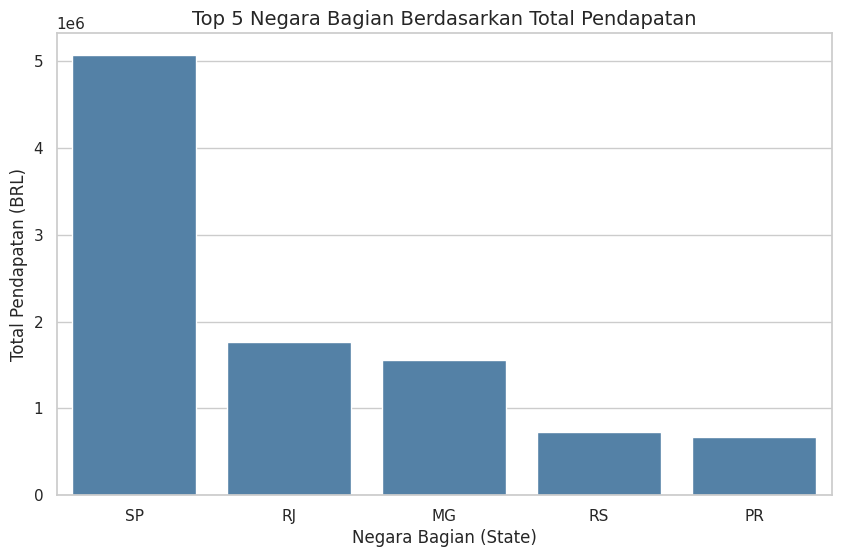

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="customer_state",
    y="price",
    data=state_revenue.head(5),
    color="steelblue"
)

plt.title("Top 5 Negara Bagian Berdasarkan Total Pendapatan", fontsize=14)
plt.xlabel("Negara Bagian (State)", fontsize=12)
plt.ylabel("Total Pendapatan (BRL)", fontsize=12)

# Menampilkan grafik
plt.show()

### Pertanyaan 2:

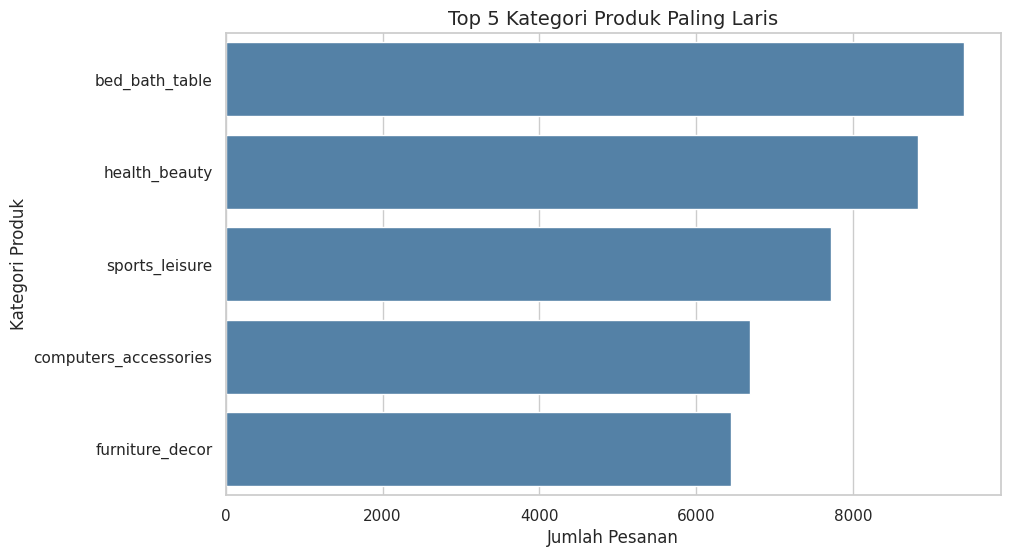

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="order_count",
    y="category_name",
    data=product_performance.head(5),
    color="steelblue"
)

plt.title("Top 5 Kategori Produk Paling Laris", fontsize=14)
plt.xlabel("Jumlah Pesanan", fontsize=12)
plt.ylabel("Kategori Produk", fontsize=12)

plt.show()

**Insight:**
- Dominasi Geografis: Analisis terhadap persebaran pendapatan menunjukkan bahwa negara bagian SP (São Paulo) merupakan pasar utama dengan total revenue yang sangat signifikan dibanding wilayah lainnya. Disusul oleh RJ (Rio de Janeiro) dan MG (Minas Gerais), temuan ini menegaskan bahwa aktivitas ekonomi e-commerce masih terpusat di wilayah Tenggara Brasil. Hal ini memberikan gambaran bagi perusahaan untuk memprioritaskan efisiensi logistik di wilayah-wilayah tersebut.

- Kategori Produk Terpopuler: Dari segi volume penjualan, kategori bed_bath_table, health_beauty, dan sports_leisure menduduki peringkat teratas. Tingginya angka pesanan pada kategori-kategori ini menunjukkan adanya minat yang konsisten dari pelanggan terhadap produk perlengkapan rumah tangga dan kesehatan.

## Analisis Lanjutan (RFM Analysis)

In [43]:
rfm_data = pd.merge(orders_df, order_items_df, on='order_id')
rfm_data = pd.merge(rfm_data, customers_df, on='customer_id')

In [44]:
rfm_df = rfm_data.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "price": "sum"
})

In [45]:
rfm_df.columns = ["customer_unique_id", "max_order_timestamp", "frequency", "monetary"]

In [46]:
recent_date = rfm_data["order_purchase_timestamp"].max()
rfm_df["recency"] = (recent_date - rfm_df["max_order_timestamp"]).dt.days

In [47]:
rfm_df["short_id"] = rfm_df["customer_unique_id"].str[:8]

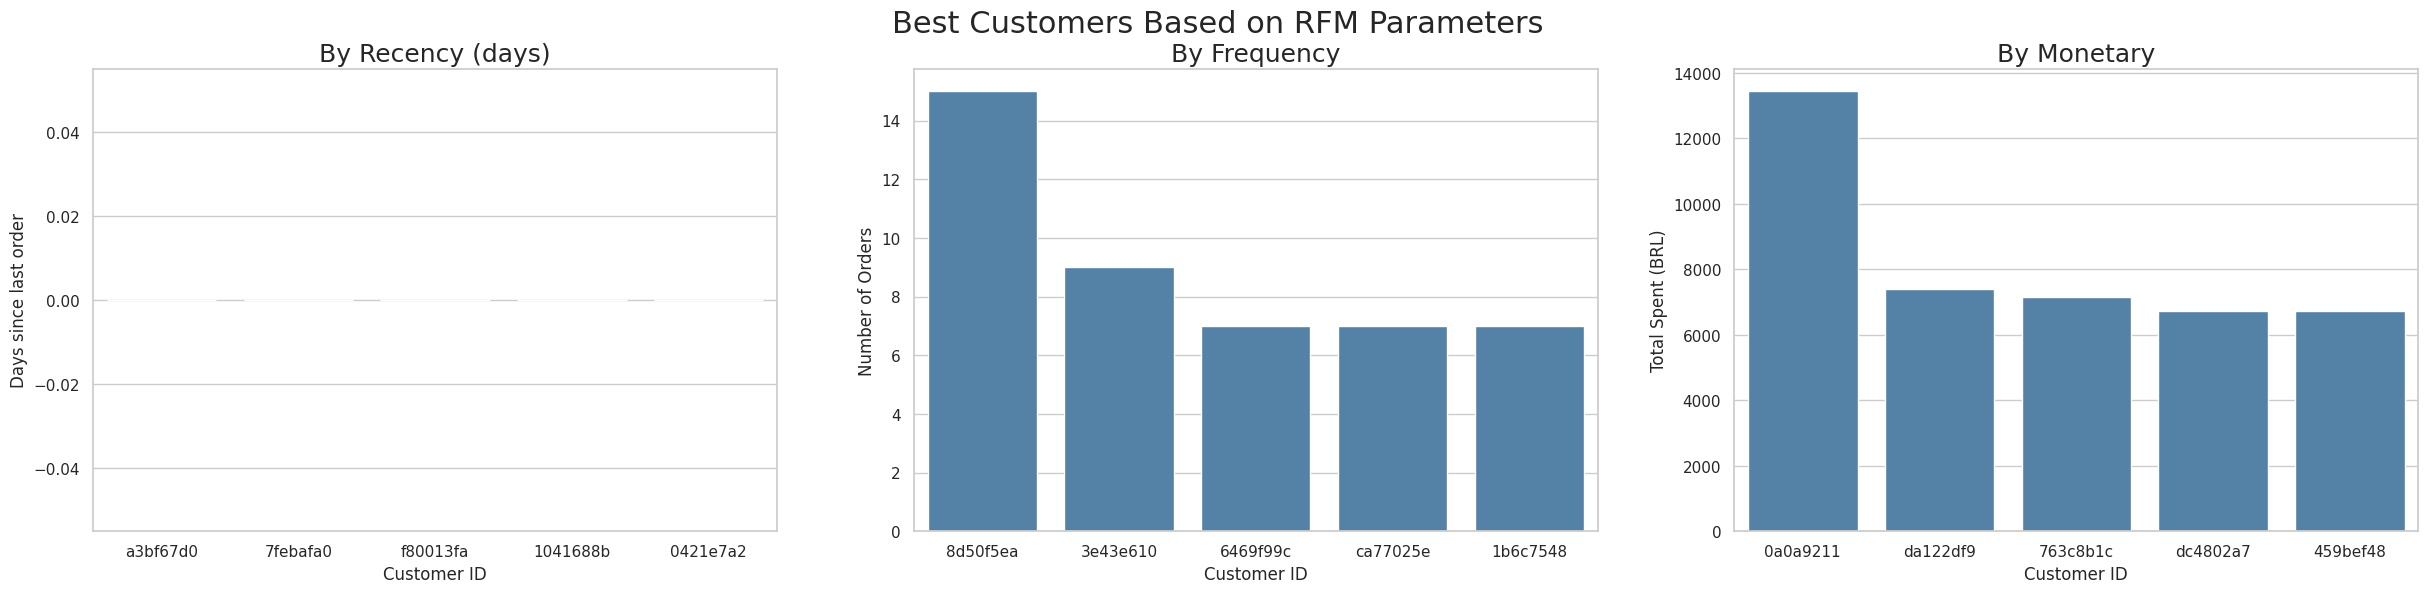

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))
colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(y="recency", x="short_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), color="steelblue", ax=ax[0])
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].set_xlabel("Customer ID")
ax[0].set_ylabel("Days since last order")

sns.barplot(y="frequency", x="short_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), color="steelblue", ax=ax[1])
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].set_xlabel("Customer ID")
ax[1].set_ylabel("Number of Orders")

sns.barplot(y="monetary", x="short_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), color="steelblue", ax=ax[2])
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].set_xlabel("Customer ID")
ax[2].set_ylabel("Total Spent (BRL)")

plt.suptitle("Best Customers Based on RFM Parameters", fontsize=22)
plt.show()

**Insight:**

**Analisis Lanjutan (RFM Analysis)**

Untuk mendapatkan pemahaman yang lebih dalam mengenai perilaku pelanggan, dilakukan RFM Analysis (Recency, Frequency, Monetary). Berdasarkan visualisasi di atas, terdapat beberapa temuan menarik:

- Recency: Terdapat pelanggan-pelanggan aktif yang baru saja melakukan transaksi dalam beberapa hari terakhir dari tanggal batas dataset. Ini menunjukkan platform masih memiliki traffic yang hidup.

- Frequency & Monetary: Meskipun mayoritas pelanggan hanya melakukan satu kali transaksi (one-time buyer), terdapat segmen pelanggan eksklusif (VIP) yang melakukan transaksi berkali-kali dengan nilai total pembelanjaan (monetary) yang sangat tinggi, mencapai ribuan BRL.

**Rekomendasi Berdasarkan RFM:**

- Perusahaan perlu membuat program loyalitas (seperti Customer Retention Program atau poin rewards) yang ditargetkan khusus untuk pelanggan dengan nilai Frequency dan Monetary tinggi. Karena mendapatkan pelanggan baru jauh lebih mahal daripada mempertahankan pelanggan lama, memberikan penawaran eksklusif kepada top pelanggan ini akan sangat menjaga stabilitas pendapatan perusahaan ke depannya.

## Conclusion

# **Pertanyaan 1: Negara Bagian dengan Pendapatan Tertinggi (Tahun 2018)**

Melalui analisis data transaksi dengan status pesanan "delivered" sepanjang tahun 2018, negara bagian SP (São Paulo) secara konsisten menempati urutan pertama sebagai wilayah penghasil total pendapatan (revenue) tertinggi bagi perusahaan. Hal ini mengonfirmasi bahwa São Paulo merupakan pasar yang paling matang dan produktif, sehingga strategi efisiensi logistik dan alokasi sumber daya operasional harus diprioritaskan pada wilayah ini guna menjaga stabilitas profit perusahaan di masa mendatang.

# **Pertanyaan 2: Performa 5 Kategori Produk Unggulan (Periode 2017-2018)**

Dalam rentang waktu operasional 2017 hingga 2018, lima kategori produk yang mendominasi pasar berdasarkan volume penjualan terbanyak adalah bed_bath_table, health_beauty, housewares, computers_accessories, dan sports_leisure. Terdapat korelasi positif di mana tingginya volume penjualan pada kategori-kategori tersebut juga memberikan kontribusi signifikan terhadap total pendapatan perusahaan. Hal ini menunjukkan bahwa kategori-kategori ini merupakan penggerak utama pertumbuhan bisnis yang perlu mendapatkan perhatian khusus dalam manajemen stok inventaris dan strategi promosi berkelanjutan.

**Recommendation (Action Items)**

Untuk meningkatkan performa bisnis ke depannya, berikut adalah beberapa rekomendasi yang dapat dilakukan:

- Optimalisasi Logistik dan Operasional di Wilayah Kunci: Mengingat São Paulo adalah penyumbang pendapatan terbesar, perusahaan disarankan untuk memperkuat infrastruktur logistik dan memperbanyak pusat distribusi di wilayah tersebut guna memastikan pengiriman yang lebih cepat dan biaya operasional yang lebih efisien.

In [49]:
!pip freeze > requirements.txt

In [50]:
all_df = pd.merge(orders_df, order_items_df, on='order_id')
all_df = pd.merge(all_df, customers_df, on='customer_id')
all_df = pd.merge(all_df, products_english, on='product_id')

all_df.to_parquet("all_data.parquet", index=False)